**STATUS:** ALIVE (provisional figures)  
**LAST-AUDIT:** 2026-04-25  
**FEEDS:** S1 (Fig 1 A87); F1, F2, W1 (Fig 2 Lerner); B3, B4 (Fig 3 XBID)  
**CLAIM:** Provisional thesis figures. Fig 2 needs Spec-3 axis relabelling per nb12 within-tech caveat (W1). Figures will be regenerated after nb12/nb13 narrative cleanup.

# Thesis figures (provisional)

**Status**: all figures here are **provisional**. They earn their place in
the thesis body only if the supporting narrative in
`_identification_target.md` holds up. If any of the supporting findings is
later withdrawn or narrowed, the corresponding figure is deleted from this
notebook and from the thesis.

**Scope**: three figures total, one per narrative layer:
1. **System layer** — A87 monthly financial balance
2. **Structural layer** — Big-4 monthly Lerner + price-bin-corrected
   regime contrasts (two-panel)
3. **Behavioural layer** — XBID 2×2 liquidity panel

Each figure is saved as PDF + PNG in `figures/` with a caption sidecar
for LaTeX inclusion.


In [1]:
import warnings, json
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm

from mtu.notebook_utils import (
    PROJECT_ROOT,
    IDA_REFORM, ISP15_REFORM, INTRADAY_REFORM, DAY_AHEAD_REFORM,
    add_regime_shading,
)

warnings.filterwarnings('ignore')
mpl.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

FIG_DIR = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

COLORS = {'GE':'C3', 'IB':'C0', 'GN':'C1', 'HC':'C2'}

A87 = PROJECT_ROOT / 'data/processed/entsoe/balancing/financial_balance_all.parquet'
LER = PROJECT_ROOT / 'data/derived/panels/firm_lerner_hourly.parquet'
XBID = PROJECT_ROOT / 'data/derived/panels/xbid_liquidity_hourly.parquet'

con = duckdb.connect()
con.execute("SET memory_limit='6GB'"); con.execute("SET threads=4")

def save_fig(fig, name, caption):
    pdf_path = FIG_DIR / f'{name}.pdf'
    png_path = FIG_DIR / f'{name}.png'
    fig.savefig(pdf_path, bbox_inches='tight')
    fig.savefig(png_path, bbox_inches='tight', dpi=150)
    (FIG_DIR / f'{name}.caption.json').write_text(
        json.dumps({'caption': caption, 'figure_id': name}, indent=2))
    print(f'  → saved {pdf_path.name} + .png + .caption.json')
    return fig


## Fig 1 — A87 monthly financial balance (system layer)

The strongest single data point for the reform's system-level signature.
Two series: A01 (TSO→BSPs) expenses and A02 (BRPs→TSO) net income.
The net-income line tells the story cleanly.


  → saved fig1_a87_financial_balance.pdf + .png + .caption.json


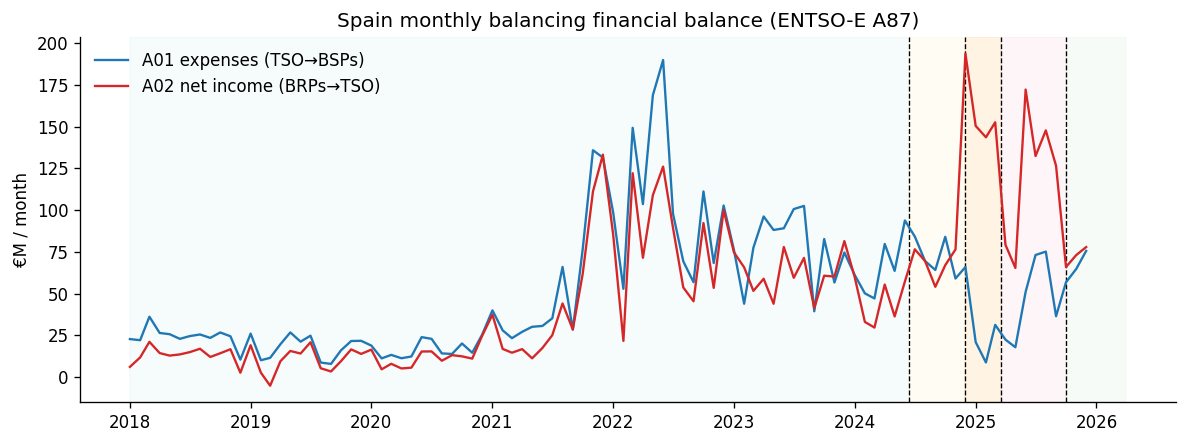

In [2]:
df = con.sql(f'''
    SELECT month,
           MAX(CASE WHEN direction_code='A01' THEN amount_eur END)/1e6 AS expenses_meur,
           MAX(CASE WHEN direction_code='A02' THEN amount_eur END)/1e6 AS net_income_meur
    FROM '{A87}'
    GROUP BY month ORDER BY month
''').df()
df['month'] = pd.to_datetime(df['month'])

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(df['month'], df['expenses_meur'],   color='C0', lw=1.4,
        label='A01 expenses (TSO→BSPs)')
ax.plot(df['month'], df['net_income_meur'], color='C3', lw=1.4,
        label='A02 net income (BRPs→TSO)')
add_regime_shading(ax, start='2018-01-01', end='2026-04-01')
ax.set_ylabel('€M / month')
ax.set_title('Spain monthly balancing financial balance (ENTSO-E A87)')
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
save_fig(fig, 'fig1_a87_financial_balance',
    'Monthly balancing financial balance for Spain, TR 17.1.i. '
    'Expenses (blue) represent TSO payments to balancing-service providers; '
    'net income (red) represents imbalance-settlement receipts from BRPs. '
    'Net income jumps from ~€38M/mo pre-reform to €160M/mo at ISP15 '
    '(1 Dec 2024), reflecting the elimination of intra-hour imbalance netting; '
    'it moderates to €72M/mo at MTU15-DA as 15-min trading tools spread '
    'across markets.')
plt.show()


## Fig 2 — Big-4 Lerner: monthly time-series + price-bin-corrected regime contrasts

**Two-panel structural-layer figure.**

- **Panel A (top, descriptive)**: monthly median Lerner per Big-4 firm,
  with regime shading. Shows the time profile of the elevation.
- **Panel B (bottom, quantitative)**: price-bin-corrected regime contrasts
  vs pre-IDA reference, with 95% confidence intervals (HC3 SE). Spec is
  $L_i \sim \text{regime} + \text{p\_bin FE}$ with price bins
  $\{$ neg, 0–25, 25–50, 50–100, 100–200, 200+ $\}$ €/MWh, fitted per
  firm.

The bottom panel carries the rigorous claim: at the same clearing-price
level, **GE and IB** show DA60/ID15 elevation of +0.318 and +0.135 above
pre-IDA respectively, with partial reversal at MTU15-DA.

Reproducing: `scripts/analysis/seasonal_correction_lerner.py`. Spec
rationale and full numbers in `_robustness_summary.md` §7.


  → saved fig2_big4_lerner_monthly.pdf + .png + .caption.json


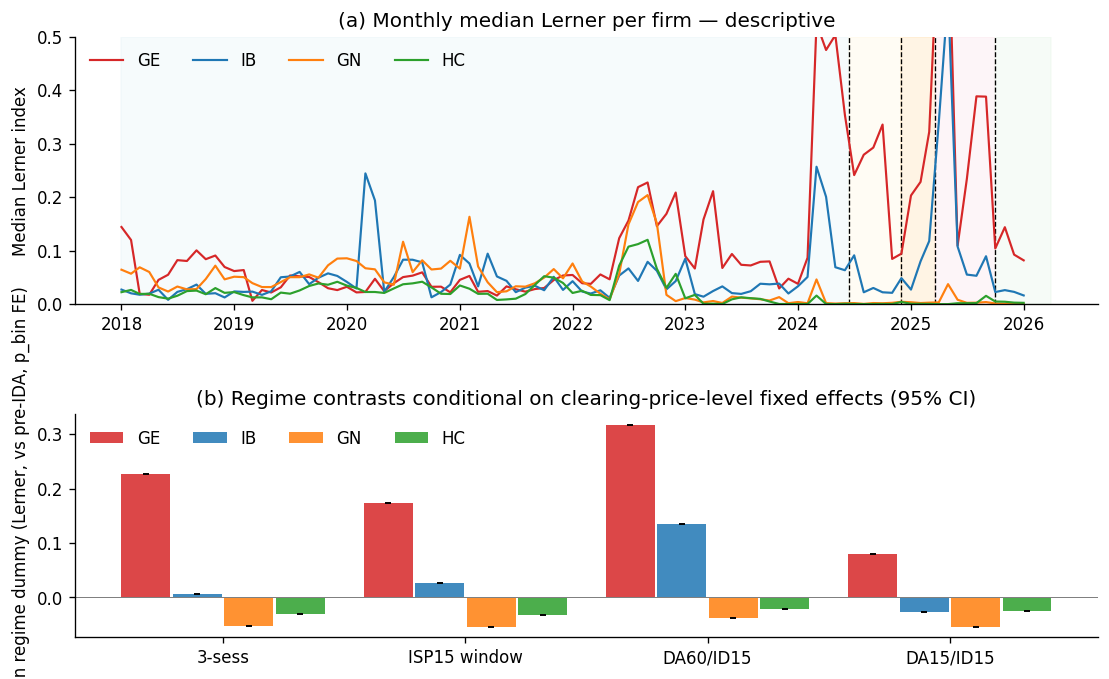


Panel B underlying numbers:
                    coef   se    p
firm regime                       
GE   3-sess        0.226  0.0  0.0
     ISP15 window  0.174  0.0  0.0
     DA60/ID15     0.318  0.0  0.0
     DA15/ID15     0.080  0.0  0.0
IB   3-sess        0.006  0.0  0.0
     ISP15 window  0.027  0.0  0.0
     DA60/ID15     0.135  0.0  0.0
     DA15/ID15    -0.028  0.0  0.0
GN   3-sess       -0.053  0.0  0.0
     ISP15 window -0.054  0.0  0.0
     DA60/ID15    -0.038  0.0  0.0
     DA15/ID15    -0.055  0.0  0.0
HC   3-sess       -0.031  0.0  0.0
     ISP15 window -0.032  0.0  0.0
     DA60/ID15    -0.022  0.0  0.0
     DA15/ID15    -0.024  0.0  0.0


In [3]:
df = con.sql(f'''
    SELECT date, firm, lerner_index, clearing_price_eur_mwh AS p
    FROM '{LER}'
    WHERE lerner_index BETWEEN 0 AND 1
''').df()
df['date'] = pd.to_datetime(df['date'])
df['ym'] = df['date'].dt.to_period('M').dt.to_timestamp()

def assign_regime(d):
    d = pd.Timestamp(d)
    if d < IDA_REFORM:        return 'pre-IDA'
    if d < ISP15_REFORM:      return '3-sess'
    if d < INTRADAY_REFORM:   return 'ISP15 window'
    if d < DAY_AHEAD_REFORM:  return 'DA60/ID15'
    return 'DA15/ID15'
df['regime'] = df['date'].apply(assign_regime)
df['p_bin'] = pd.cut(df['p'], bins=[-1000, 0, 25, 50, 100, 200, 1e6],
                     labels=['neg','0-25','25-50','50-100','100-200','200+'])

REGIME_ORDER = ['pre-IDA', '3-sess', 'ISP15 window', 'DA60/ID15', 'DA15/ID15']

# Panel A: monthly medians
monthly = df.groupby(['ym','firm'])['lerner_index'].median().reset_index()

# Panel B: price-bin-corrected OLS contrasts per firm
firms = ['GE','IB','GN','HC']
post_regimes = ['3-sess','ISP15 window','DA60/ID15','DA15/ID15']
contrast_rows = []
for firm in firms:
    sub = df[df['firm']==firm].copy()
    sub['regime_cat'] = pd.Categorical(sub['regime'], categories=REGIME_ORDER, ordered=False)
    rd = pd.get_dummies(sub['regime_cat'], prefix='regime', drop_first=False, dtype=float)
    rd = rd.drop(columns='regime_pre-IDA')
    pd_dum = pd.get_dummies(sub['p_bin'], prefix='p_bin', drop_first=True, dtype=float)
    X = pd.concat([rd, pd_dum], axis=1).assign(const=1.0)
    y = sub['lerner_index'].astype(float)
    res = sm.OLS(y, X).fit(cov_type='HC3')
    for r in post_regimes:
        col = f'regime_{r}'
        contrast_rows.append({
            'firm': firm, 'regime': r,
            'coef': res.params[col],
            'se':   res.bse[col],
            'ci_lo': res.params[col] - 1.96*res.bse[col],
            'ci_hi': res.params[col] + 1.96*res.bse[col],
            'p':    res.pvalues[col],
        })
contrasts = pd.DataFrame(contrast_rows)

# Build figure
fig = plt.figure(figsize=(11, 6.5))
gs = fig.add_gridspec(2, 1, height_ratios=[1.2, 1.0], hspace=0.45)

# Panel A: monthly time series
axA = fig.add_subplot(gs[0])
for f in firms:
    sub = monthly[monthly['firm']==f]
    axA.plot(sub['ym'], sub['lerner_index'], color=COLORS[f], lw=1.3, label=f)
add_regime_shading(axA, start='2018-01-01', end='2026-04-01')
axA.set_ylabel('Median Lerner index')
axA.set_title('(a) Monthly median Lerner per firm — descriptive')
axA.legend(loc='upper left', frameon=False, ncol=4)
axA.set_ylim(0, 0.5)

# Panel B: regime contrasts
axB = fig.add_subplot(gs[1])
n_firms = len(firms)
n_regimes = len(post_regimes)
xpos = np.arange(n_regimes)
width = 0.85 / n_firms
for i, f in enumerate(firms):
    sub = contrasts[contrasts['firm']==f].set_index('regime').reindex(post_regimes)
    pos = xpos + (i - n_firms/2 + 0.5) * width
    err = np.array([
        sub['coef'].values - sub['ci_lo'].values,
        sub['ci_hi'].values - sub['coef'].values,
    ])
    axB.bar(pos, sub['coef'].values, width=width*0.95,
            color=COLORS[f], label=f, alpha=0.85)
    axB.errorbar(pos, sub['coef'].values, yerr=err,
                 fmt='none', color='black', lw=0.7, capsize=2)
axB.axhline(0, color='grey', lw=0.6)
axB.set_xticks(xpos)
axB.set_xticklabels(post_regimes)
axB.set_ylabel('OLS coef on regime dummy (Lerner, vs pre-IDA, p_bin FE)')
axB.set_title('(b) Regime contrasts conditional on clearing-price-level fixed effects (95% CI)')
axB.legend(loc='upper left', frameon=False, ncol=4)
plt.tight_layout()
save_fig(fig, 'fig2_big4_lerner_monthly',
    'Big-4 implied Lerner index. (a) Monthly median per firm with regime '
    'shading: descriptive time profile. (b) Regime contrasts vs pre-IDA '
    'reference, conditional on clearing-price-bin fixed effects, with 95% '
    'CIs. The price-bin control is the cleanest available control for the '
    'low-price seasonal artefact that mechanically inflates the static-FOC '
    'Lerner formula. Endesa (GE) and Iberdrola (IB) show DA60/ID15 '
    'elevation of +0.318 and +0.135 above pre-IDA at matched prices '
    '(p<0.001), with partial reversal at MTU15-DA (GE +0.080, IB −0.028). '
    'Naturgy (GN) and HC-Energía (HC) show small or below-baseline '
    'contrasts across all post-reform regimes, dominated by bilateral-'
    'contract reallocation at the March 2025 Rule 28.8 elimination, not '
    'by strategic bidding.')
plt.show()

print()
print('Panel B underlying numbers:')
print(contrasts.set_index(['firm','regime'])[['coef','se','p']].round(3).to_string())


## Fig 3 — XBID 2×2 liquidity panel (behavioural layer)

Four-panel view of continuous-intraday liquidity: orders/hour, trades/hour,
fill rate, and trade-price dispersion. All four show the DA60/ID15 peak
and partial moderation at MTU15-DA, concordant with Fig 2 panel (b).


  → saved fig3_xbid_liquidity.pdf + .png + .caption.json


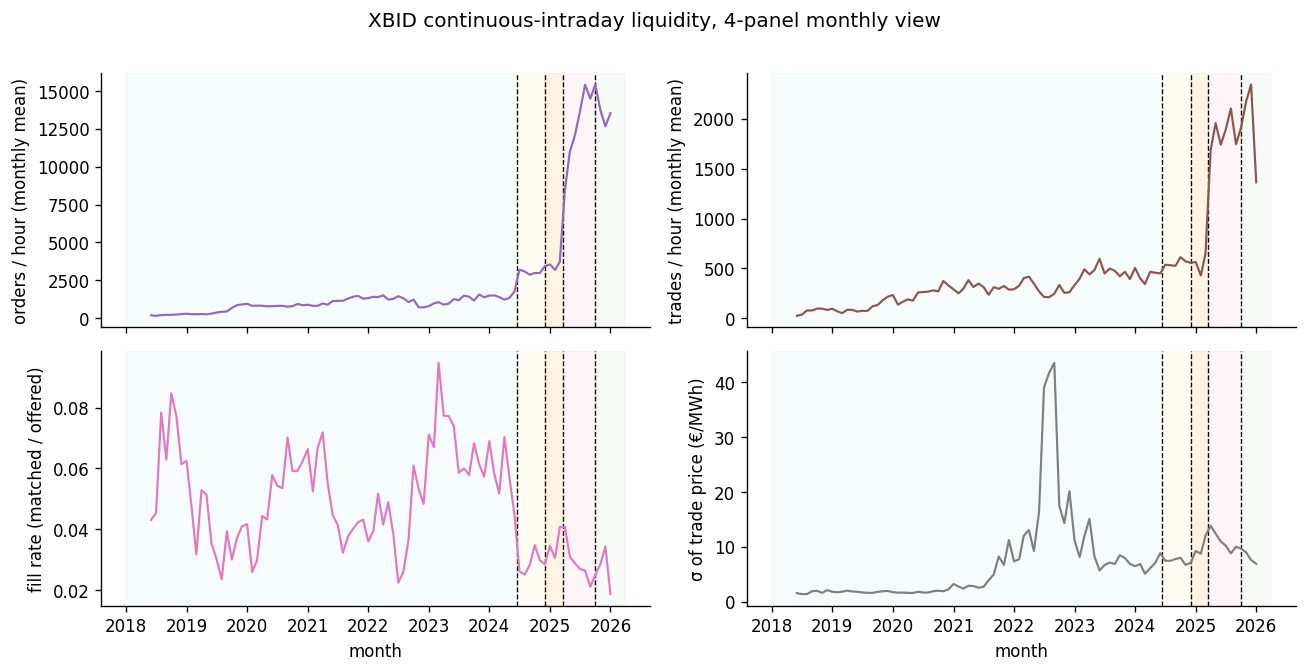

In [4]:
df = con.sql(f'''
    SELECT date, n_orders, n_trades, fill_rate, sd_trade_price
    FROM '{XBID}'
''').df()
df['date'] = pd.to_datetime(df['date'])
df['ym'] = df['date'].dt.to_period('M').dt.to_timestamp()
monthly = df.groupby('ym').agg(
    orders=('n_orders','mean'),
    trades=('n_trades','mean'),
    fill=('fill_rate','mean'),
    sd_p=('sd_trade_price','mean'),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(11, 5.5), sharex=True)
panels = [
    (axes[0,0], 'orders',  'orders / hour (monthly mean)',      'C4'),
    (axes[0,1], 'trades',  'trades / hour (monthly mean)',       'C5'),
    (axes[1,0], 'fill',    'fill rate (matched / offered)',      'C6'),
    (axes[1,1], 'sd_p',    'σ of trade price (€/MWh)',           'C7'),
]
for ax, col, ylab, color in panels:
    ax.plot(monthly['ym'], monthly[col], color=color, lw=1.3)
    add_regime_shading(ax, start='2018-01-01', end='2026-04-01')
    ax.set_ylabel(ylab)
axes[1,0].set_xlabel('month')
axes[1,1].set_xlabel('month')
fig.suptitle('XBID continuous-intraday liquidity, 4-panel monthly view', y=1.01)
plt.tight_layout()
save_fig(fig, 'fig3_xbid_liquidity',
    'XBID continuous-intraday liquidity, monthly means. Orders per hour '
    'grow 15× from pre-IDA (~920) to DA15/ID15 (~13,900); fill rate falls '
    'from 5.2% to 2.7% as granularity finer; trade-price dispersion peaks '
    'at DA60/ID15 (€11.3/MWh) and normalises at MTU15-DA — concordant with '
    'the structural-markup pattern in Fig 2 panel (b).')
plt.show()


---

## Status tracker

| Figure | Supporting narrative | Status (2026-04-25) |
|---|---|---|
| 1. A87 financial balance | nb11 §1, _id_target.md D14 four-way concordance at ISP15 | **provisional**, robust to all checks |
| 2. Big-4 Lerner (2-panel) | nb12 + _robustness_summary.md §7 | **provisional**, panel (b) carries the quantitative claim post seasonal correction |
| 3. XBID liquidity | nb13 §2 behavioural-layer corroboration | **provisional**, robust |

Delete a figure from this notebook **and** from `figures/` if its
supporting narrative is later withdrawn.

### Note on Fig 2 update (2026-04-25)

Original v1 fig2 was the monthly time series only. The seasonal-correction
robustness check (`_robustness_summary.md` §6-§7) showed that the raw monthly
time series is descriptively informative but the Hortaçsu-Puller formula
mechanically inflates at low-price hours, so a price-bin-corrected regime-
contrast panel was added as panel (b) to carry the rigorous claim. The
descriptive monthly trace is kept as panel (a) for context.
